# Parameter Permutation Sweeps with RasPermutation

Generate Cartesian products of parameter ranges, automatically
partition into batch folders (respecting the 99-plan HEC-RAS limit),
execute in parallel, and collect results into audit-friendly CSV logs.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if (
    not (repo_root / "ras_commander").exists()
    and (repo_root.parent / "ras_commander").exists()
):
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import ras_commander as ras_commander_pkg
from ras_commander import *
from ras_commander import RasPermutation, setup_logging
from ras_commander.hdf import HdfResultsXsec

import logging
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

setup_logging(log_level=logging.WARNING)
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("ras_commander").setLevel(logging.WARNING)

plt.style.use("default")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


## Setup & Project Extraction

Start with the reproducible `Muncie` example project, remove any old
permutation demo folders from prior runs, and inspect the existing
plans in `ras.plan_df`.


In [2]:
project_name = "Muncie"
working_root = repo_root / "working" / "114_parameter_permutation"
working_root.mkdir(parents=True, exist_ok=True)

suffix = "parameter_permutation_demo"
template_plan = "01"

try:
    project_path = RasExamples.extract_project(
        project_name,
        output_path=working_root,
    )
except RuntimeError as exc:
    fallback_path = working_root / project_name
    if (
        "failed to delete existing folder" in str(exc).lower()
        and fallback_path.exists()
    ):
        project_path = fallback_path
        print(
            "Using the existing extracted project because "
            "the working copy could not be deleted cleanly."
        )
    else:
        raise

ras = init_ras_project(project_path, get_ras_exe("6.6"))

master_log_path = project_path.parent / (
    f"{project_path.name}_{suffix}_master_log.csv"
)

for batch_folder in RasPermutation.discover_batch_folders(
    project_path,
    suffix=suffix,
):
    shutil.rmtree(batch_folder, ignore_errors=True)

master_log_path.unlink(missing_ok=True)

available_slots = 99 - len(ras.plan_df)
template_plan_mask = (
    ras.plan_df["plan_number"].astype(str).str.zfill(2)
    == template_plan
)
plan_overview = (
    ras.plan_df[["plan_number", "Plan Title", "Short Identifier"]]
    .sort_values("plan_number")
    .reset_index(drop=True)
)

template_plan_row = ras.plan_df.loc[template_plan_mask].iloc[0]
template_geom_number = str(
    template_plan_row["geometry_number"]
).zfill(2)
template_unsteady_number = str(
    template_plan_row["unsteady_number"]
).zfill(2)
template_geom_path = Path(template_plan_row["Geom Path"])
template_unsteady_path = Path(template_plan_row["Flow Path"])

cross_sections_df = GeomCrossSection.get_cross_sections(
    template_geom_path,
    river="White",
    reach="Muncie",
)

valid_rs = []
base_mannings_by_rs = {}
for rs in cross_sections_df["RS"].astype(str):
    try:
        base_mannings_by_rs[rs] = GeomCrossSection.get_mannings_n(
            template_geom_path,
            "White",
            "Muncie",
            rs,
        )
        valid_rs.append(rs)
    except ValueError:
        continue

monitor_stations = {
    "upstream_boundary": "15696.24",
    "mid_reach": "14535.60",
    "downstream_control": "237.6455",
}
base_channel_n = float(
    base_mannings_by_rs[monitor_stations["mid_reach"]]
    .loc[
        lambda df: df["Subsection"] == "Channel",
        "n_value",
    ]
    .iloc[0]
)

assert project_path.exists(), "Example project extraction failed"
assert template_plan_mask.any(), "Template plan 01 must exist"
assert available_slots >= 15, "Need room for all 15 permutations"
assert len(valid_rs) == 61, "Expected 61 XS with Manning data"
assert all(
    station in valid_rs for station in monitor_stations.values()
)

print(f"Project folder: {project_path}")
print(f"Working root: {working_root}")
print(
    "Using ras_commander from: "
    f"{Path(ras_commander_pkg.__file__).resolve()}"
)
print(f"Existing plans: {len(ras.plan_df)}")
print(
    "Available new-plan slots before the 99-plan ceiling: "
    f"{available_slots}"
)
print(f"Template geometry: g{template_geom_number}")
print(f"Template unsteady flow: u{template_unsteady_number}")
print(f"Valid XS with Manning data: {len(valid_rs)}")
print(f"Base main-channel n in the template plan: {base_channel_n:.2f}")
print(
    "Monitoring stations: "
    + ", ".join(
        f"{name}={station}"
        for name, station in monitor_stations.items()
    )
)
display(plan_overview)
display(
    cross_sections_df[
        ["River", "Reach", "RS", "Length_Channel"]
    ].head()
)


Project folder: C:\GH\ras-commander\working\114_parameter_permutation\Muncie
Working root: C:\GH\ras-commander\working\114_parameter_permutation
Using ras_commander from: C:\GH\ras-commander\ras_commander\__init__.py
Existing plans: 3
Available new-plan slots before the 99-plan ceiling: 96
Template geometry: g01
Template unsteady flow: u01
Valid XS with Manning data: 61
Base main-channel n in the template plan: 0.04
Monitoring stations: upstream_boundary=15696.24, mid_reach=14535.60, downstream_control=237.6455


,plan_number,Plan Title,Short Identifier
0,01,Unsteady Multi 9-SA run,9-SAs
1,03,Unsteady Run with 2D 50ft Grid,2D 50ft Grid
2,04,Unsteady Run with 2D 50ft User n Value R,50ft User n Regions


,River,Reach,RS,Length_Channel
0,White,Muncie,15696.24,210.73
1,White,Muncie,15485.51,115.09
2,White,Muncie,15370.43,165.14
3,White,Muncie,15205.29,192.09
4,White,Muncie,15013.20,95.84


## Define Parameters

`RasPermutation.define_parameters()` accepts plain value lists and
`RangeSpec` objects. Here the sweep uses three Manning's `n` values
and five width values, which yields a 15-row Cartesian product with
a stable `absolute_perm_id`.


In [3]:
parameter_spec = {
    "channel_n": [0.03, 0.04, 0.05],
    "inflow_multiplier": [0.8, 0.9, 1.0, 1.1, 1.2],
}

expected_channel_n_values = [0.03, 0.04, 0.05]
expected_multiplier_values = [0.8, 0.9, 1.0, 1.1, 1.2]
parameters_df = RasPermutation.define_parameters(parameter_spec)
baseline_mask = (
    np.isclose(parameters_df["channel_n"], base_channel_n)
    & np.isclose(parameters_df["inflow_multiplier"], 1.0)
)

assert sorted(parameters_df["channel_n"].unique().tolist()) == (
    expected_channel_n_values
)
assert sorted(
    parameters_df["inflow_multiplier"].unique().tolist()
) == expected_multiplier_values
assert len(parameters_df) == 15
assert parameters_df["absolute_perm_id"].tolist() == list(
    range(1, len(parameters_df) + 1)
)
assert not parameters_df[
    ["channel_n", "inflow_multiplier"]
].duplicated().any()
assert baseline_mask.sum() == 1

print(
    f"{parameters_df['channel_n'].nunique()} channel roughness values x "
    f"{parameters_df['inflow_multiplier'].nunique()} inflow multipliers = "
    f"{len(parameters_df)} permutations"
)
print("Baseline case is channel_n=0.04 and inflow_multiplier=1.00")
display(parameters_df)


3 channel roughness values x 5 inflow multipliers = 15 permutations
Baseline case is channel_n=0.04 and inflow_multiplier=1.00


,absolute_perm_id,channel_n,inflow_multiplier
0,1,0.03,0.8
1,2,0.03,0.9
2,3,0.03,1.0
3,4,0.03,1.1
4,5,0.03,1.2
5,6,0.04,0.8
6,7,0.04,0.9
7,8,0.04,1.0
8,9,0.04,1.1
9,10,0.04,1.2


## Cartesian Product Visualization

A compact way to see the sweep is to pivot the permutation table by
parameter values. Each heatmap cell corresponds to one row in the
permutation DataFrame, labeled by `absolute_perm_id`.


inflow_multiplier,0.8,0.9,1.0,1.1,1.2
channel_n,,,,,
0.03,1,2,3,4,5
0.04,6,7,8,9,10
0.05,11,12,13,14,15


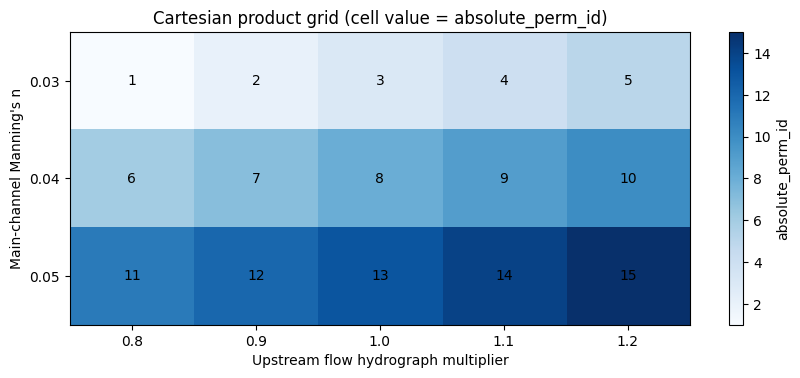

In [4]:
grid = parameters_df.pivot(
    index="channel_n",
    columns="inflow_multiplier",
    values="absolute_perm_id",
)
display(grid)

fig, ax = plt.subplots(figsize=(10, 3.8))
image = ax.imshow(grid.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(grid.columns)))
ax.set_xticklabels([f"{value:.1f}" for value in grid.columns])
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels([f"{value:.2f}" for value in grid.index])
ax.set_xlabel("Upstream flow hydrograph multiplier")
ax.set_ylabel("Main-channel Manning's n")
ax.set_title(
    "Cartesian product grid (cell value = absolute_perm_id)"
)

for row_index in range(grid.shape[0]):
    for col_index in range(grid.shape[1]):
        ax.text(
            col_index,
            row_index,
            int(grid.iloc[row_index, col_index]),
            ha="center",
            va="center",
            color="black",
            fontsize=10,
        )

plt.colorbar(image, ax=ax, label="absolute_perm_id")
plt.show()


## Generate Plans

`RasPermutation.generate_plans()` clones the template plan, applies a
custom `apply_fn`, and writes both a master CSV and a per-batch CSV.
This notebook deliberately stops at plan generation and CSV tracking:
`execute_and_summarize()` is intentionally omitted because actual
HEC-RAS execution is slow.

HEC-RAS allows at most 99 plans per project. `Muncie` starts with 3
plans, so up to 96 new plans could fit in one cloned project. To make
the batch behavior visible in a small example, the demo sets
`max_plans_per_batch=10`, which forces 15 permutations into two batch
folders.


In [5]:
def project_stem(folder):
    return next(folder.glob("*.prj")).stem


def component_path_from_df(df, number_column, number_value):
    normalized_value = str(number_value).zfill(2)
    mask = (
        df[number_column].astype(str).str.zfill(2)
        == normalized_value
    )
    row = df.loc[mask].iloc[0]

    for column in ["full_path", "Geom Path", "Flow Path"]:
        if column in row.index and pd.notna(row[column]):
            return Path(row[column])

    raise KeyError(
        f"No path column found for {number_column}={normalized_value}"
    )


def read_plan_reference(plan_path, key):
    prefix = f"{key}="
    for line in plan_path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines():
        if line.startswith(prefix):
            return line.split("=", 1)[1].strip()

    raise KeyError(f"{key} not found in {plan_path.name}")


def apply_permutation(plan_path, param_row, batch_ras):
    plan_number = plan_path.suffix[-2:]

    new_geom_number = RasPlan.clone_geom(
        template_geom_number,
        ras_object=batch_ras,
    )
    new_unsteady_number = RasPlan.clone_unsteady(
        template_unsteady_number,
        ras_object=batch_ras,
    )
    RasPlan.set_geom(
        plan_number,
        new_geom_number,
        ras_object=batch_ras,
    )
    RasPlan.set_unsteady(
        plan_number,
        new_unsteady_number,
        ras_object=batch_ras,
    )

    geom_path = component_path_from_df(
        batch_ras.geom_df,
        "geom_number",
        new_geom_number,
    )
    unsteady_path = component_path_from_df(
        batch_ras.unsteady_df,
        "unsteady_number",
        new_unsteady_number,
    )

    for rs in valid_rs:
        mann_df = base_mannings_by_rs[rs].copy()
        mann_df.loc[
            mann_df["Subsection"] == "Channel",
            "n_value",
        ] = float(param_row["channel_n"])
        GeomCrossSection.set_mannings_n(
            geom_path,
            "White",
            "Muncie",
            rs,
            mann_df[["Station", "n_value"]],
        )

    updated = RasUnsteady.update_flow_multiplier_by_station(
        unsteady_path,
        river_station=monitor_stations["upstream_boundary"],
        new_multiplier=float(param_row["inflow_multiplier"]),
    )
    assert updated, "Expected upstream hydrograph multiplier update"

    description = "\n".join(
        [
            "Executed parameter permutation demo",
            f"absolute_perm_id={int(param_row['absolute_perm_id'])}",
            f"channel_n={float(param_row['channel_n']):.3f}",
            (
                "inflow_multiplier="
                f"{float(param_row['inflow_multiplier']):.2f}"
            ),
            f"updated_cross_sections={len(valid_rs)}",
            (
                "boundary_station="
                f"{monitor_stations['upstream_boundary']}"
            ),
        ]
    )
    RasPlan.update_plan_description(
        plan_number,
        description,
        ras_object=batch_ras,
    )


def permutation_plan_path(batch_folder, plan_number):
    return batch_folder / (
        f"{project_stem(batch_folder)}.p{int(plan_number):02d}"
    )


plan_matrix = RasPermutation.generate_plans(
    template_plan=template_plan,
    parameters_df=parameters_df,
    apply_fn=apply_permutation,
    suffix=suffix,
    max_plans_per_batch=10,
)

master_log_df = pd.read_csv(plan_matrix["master_log"])
first_batch_folder = plan_matrix["batch_folders"][0]
first_batch_log_path = first_batch_folder / "permutations_log.csv"
first_batch_log_df = pd.read_csv(first_batch_log_path)
batch_folder_lookup = {
    folder.name: folder for folder in plan_matrix["batch_folders"]
}

expected_master_columns = [
    "absolute_perm_id",
    "batch_folder",
    "batch_index",
    "plan_number",
    "short_id",
    "plan_title",
    "channel_n",
    "inflow_multiplier",
]
generated_plan_paths = [
    permutation_plan_path(
        batch_folder_lookup[row.batch_folder],
        row.plan_number,
    )
    for row in master_log_df.itertuples(index=False)
]
first_batch_rows = master_log_df.loc[
    master_log_df["batch_folder"] == first_batch_folder.name
].reset_index(drop=True)

assert plan_matrix["total_permutations"] == len(parameters_df)
assert plan_matrix["master_log"] == master_log_path
assert plan_matrix["master_log"].exists()
assert len(plan_matrix["batch_folders"]) == plan_matrix["batches"]
assert master_log_df.columns.tolist() == expected_master_columns
assert len(master_log_df) == len(parameters_df)
assert master_log_df["absolute_perm_id"].tolist() == (
    parameters_df["absolute_perm_id"].tolist()
)
assert master_log_df["absolute_perm_id"].is_unique
assert master_log_df["plan_number"].between(1, 99).all()
assert first_batch_log_path.exists()
assert len(first_batch_log_df) == len(first_batch_rows)
assert first_batch_log_df["absolute_perm_id"].tolist() == (
    first_batch_rows["absolute_perm_id"].tolist()
)
for batch_folder in plan_matrix["batch_folders"]:
    assert batch_folder.exists()
    assert (batch_folder / f"{project_stem(batch_folder)}.prj").exists()
    assert (batch_folder / "permutations_log.csv").exists()
assert all(path.exists() for path in generated_plan_paths)

first_generated_row = master_log_df.iloc[0]
first_generated_plan_path = generated_plan_paths[0]
first_generated_plan_text = first_generated_plan_path.read_text(
    encoding="utf-8",
    errors="ignore",
)
for expected_line in [
    "Executed parameter permutation demo",
    (
        "absolute_perm_id="
        f"{int(first_generated_row['absolute_perm_id'])}"
    ),
    f"channel_n={first_generated_row['channel_n']:.3f}",
    (
        "inflow_multiplier="
        f"{first_generated_row['inflow_multiplier']:.2f}"
    ),
    f"updated_cross_sections={len(valid_rs)}",
]:
    assert expected_line in first_generated_plan_text

first_geom_ref = read_plan_reference(
    first_generated_plan_path,
    "Geom File",
)
first_flow_ref = read_plan_reference(
    first_generated_plan_path,
    "Flow File",
)
assert first_geom_ref != f"g{template_geom_number}"
assert first_flow_ref != f"u{template_unsteady_number}"

first_geom_path = first_batch_folder / (
    f"{project_stem(first_batch_folder)}.{first_geom_ref}"
)
first_unsteady_path = first_batch_folder / (
    f"{project_stem(first_batch_folder)}.{first_flow_ref}"
)
assert first_geom_path.exists()
assert first_unsteady_path.exists()

first_geom_mann_df = GeomCrossSection.get_mannings_n(
    first_geom_path,
    "White",
    "Muncie",
    monitor_stations["downstream_control"],
)
first_channel_n = float(
    first_geom_mann_df.loc[
        first_geom_mann_df["Subsection"] == "Channel",
        "n_value",
    ].iloc[0]
)
assert np.isclose(first_channel_n, first_generated_row["channel_n"])

first_unsteady_text = first_unsteady_path.read_text(
    encoding="utf-8",
    errors="ignore",
)
expected_qmult = (
    "Flow Hydrograph QMult= "
    f"{float(first_generated_row['inflow_multiplier'])}"
)
assert expected_qmult in first_unsteady_text

print(f"Master log: {plan_matrix['master_log'].name}")
print(
    "Batch folders: "
    f"{[folder.name for folder in plan_matrix['batch_folders']]}"
)
print(f"Total permutations: {plan_matrix['total_permutations']}")
print(f"Batch count: {plan_matrix['batches']}")
print(f"First generated plan: {first_generated_plan_path.name}")
print(
    f"First generated geometry clone: {first_geom_path.name} "
    f"(channel_n={first_channel_n:.3f})"
)
print(
    "First generated unsteady clone: "
    f"{first_unsteady_path.name} ({expected_qmult})"
)
print()
print("Master log preview")
display(master_log_df.head())
print("First batch log preview")
display(first_batch_log_df.head())


Master log: Muncie_parameter_permutation_demo_master_log.csv
Batch folders: ['Muncie_parameter_permutation_demo_001', 'Muncie_parameter_permutation_demo_002']
Total permutations: 15
Batch count: 2
First generated plan: Muncie.p02
First generated geometry clone: Muncie.g03 (channel_n=0.030)
First generated unsteady clone: Muncie.u02 (Flow Hydrograph QMult= 0.8)

Master log preview


,absolute_perm_id,batch_folder,batch_index,plan_number,short_id,plan_title,channel_n,inflow_multiplier
0,1,Muncie_parameter_permutation_demo_001,1,2,9-SASP00001,Unsteady Multi 9-SA run Perm 00001,0.03,0.8
1,2,Muncie_parameter_permutation_demo_001,1,5,9-SASP00002,Unsteady Multi 9-SA run Perm 00002,0.03,0.9
2,3,Muncie_parameter_permutation_demo_001,1,6,9-SASP00003,Unsteady Multi 9-SA run Perm 00003,0.03,1.0
3,4,Muncie_parameter_permutation_demo_001,1,7,9-SASP00004,Unsteady Multi 9-SA run Perm 00004,0.03,1.1
4,5,Muncie_parameter_permutation_demo_001,1,8,9-SASP00005,Unsteady Multi 9-SA run Perm 00005,0.03,1.2


First batch log preview


,absolute_perm_id,plan_number,plan_title,channel_n,inflow_multiplier
0,1,2,Unsteady Multi 9-SA run Perm 00001,0.03,0.8
1,2,5,Unsteady Multi 9-SA run Perm 00002,0.03,0.9
2,3,6,Unsteady Multi 9-SA run Perm 00003,0.03,1.0
3,4,7,Unsteady Multi 9-SA run Perm 00004,0.03,1.1
4,5,8,Unsteady Multi 9-SA run Perm 00005,0.03,1.2


## Batch Folder Organization

The master log tracks every permutation across all batch folders,
while each batch folder keeps its own local `permutations_log.csv`.
The tree preview below makes the folder layout explicit.


Effective batch size = min(99 plan ceiling, 10 requested, 96 available slots) = 10

Master CSV preview
absolute_perm_id,batch_folder,batch_index,plan_number,short_id,plan_title,channel_n,inflow_multiplier
1,Muncie_parameter_permutation_demo_001,1,02,9-SASP00001,Unsteady Multi  9-SA run Perm 00001,0.03,0.8
2,Muncie_parameter_permutation_demo_001,1,05,9-SASP00002,Unsteady Multi  9-SA run Perm 00002,0.03,0.9
3,Muncie_parameter_permutation_demo_001,1,06,9-SASP00003,Unsteady Multi  9-SA run Perm 00003,0.03,1.0
4,Muncie_parameter_permutation_demo_001,1,07,9-SASP00004,Unsteady Multi  9-SA run Perm 00004,0.03,1.1
5,Muncie_parameter_permutation_demo_001,1,08,9-SASP00005,Unsteady Multi  9-SA run Perm 00005,0.03,1.2

Per-batch CSV preview
absolute_perm_id,plan_number,plan_title,channel_n,inflow_multiplier
1,02,Unsteady Multi  9-SA run Perm 00001,0.03,0.8
2,05,Unsteady Multi  9-SA run Perm 00002,0.03,0.9
3,06,Unsteady Multi  9-SA run Perm 00003,0.03,1.0
4,07,Unsteady Multi  9-SA run Perm 00004,0.0

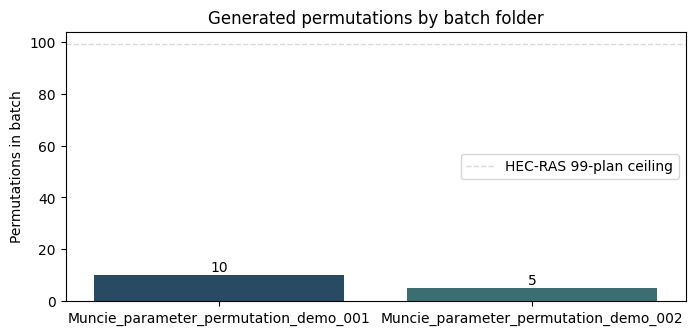

In [6]:
effective_batch_size = min(99, 10, available_slots)
expected_batches = -(-len(parameters_df) // effective_batch_size)
full_batches, remainder = divmod(
    len(parameters_df),
    effective_batch_size,
)
expected_batch_sizes = [effective_batch_size] * full_batches
if remainder:
    expected_batch_sizes.append(remainder)

print(
    "Effective batch size = min(99 plan ceiling, "
    f"10 requested, {available_slots} available slots) = "
    f"{effective_batch_size}"
)
print()

master_preview = "\n".join(
    plan_matrix["master_log"].read_text(
        encoding="utf-8"
    ).splitlines()[:6]
)
batch_preview = "\n".join(
    first_batch_log_path.read_text(
        encoding="utf-8"
    ).splitlines()[:6]
)

print("Master CSV preview")
print(master_preview)
print()
print("Per-batch CSV preview")
print(batch_preview)


def render_batch_tree(batch_folder):
    lines = [f"{batch_folder.name}/"]
    for path in sorted(batch_folder.iterdir()):
        suffix = path.suffix.lower()
        is_plan_file = (
            len(suffix) == 4
            and suffix.startswith(".p")
            and suffix[2:].isdigit()
        )
        is_geom_file = (
            len(suffix) == 4
            and suffix.startswith(".g")
            and suffix[2:].isdigit()
        )
        is_unsteady_file = (
            len(suffix) == 4
            and suffix.startswith(".u")
            and suffix[2:].isdigit()
        )
        if path.is_dir() and path.name == "GIS_Data":
            lines.append(f"  {path.name}/")
        elif (
            path.name == "permutations_log.csv"
            or suffix == ".prj"
            or is_plan_file
            or is_geom_file
            or is_unsteady_file
        ):
            lines.append(f"  {path.name}")
    return "\n".join(lines)


for batch_folder in plan_matrix["batch_folders"]:
    print()
    print(render_batch_tree(batch_folder))

batch_counts = (
    master_log_df.groupby("batch_folder").size().sort_index()
)
assert plan_matrix["batches"] == expected_batches
assert batch_counts.tolist() == expected_batch_sizes
assert batch_counts.sum() == len(parameters_df)
assert batch_counts.max() <= effective_batch_size

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(
    batch_counts.index,
    batch_counts.values,
    color=["#284b63", "#3c6e71"],
)
ax.axhline(
    99,
    color="#d9d9d9",
    linestyle="--",
    linewidth=1,
    label="HEC-RAS 99-plan ceiling",
)
ax.set_ylabel("Permutations in batch")
ax.set_title("Generated permutations by batch folder")
ax.legend()

for bar, count in zip(bars, batch_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        str(int(count)),
        ha="center",
        va="bottom",
    )

plt.xticks(rotation=0)
plt.show()


## Discover Batch Folders

`RasPermutation.discover_batch_folders()` is useful when you want to
resume work from an existing sweep folder without regenerating plans.
It finds folders that follow the `{project}_{suffix}_{NNN}` naming
convention and returns them in numeric order.


In [7]:
discovered_batches = RasPermutation.discover_batch_folders(
    project_path,
    suffix=suffix,
)

print("Discovered batch folders:")
for folder in discovered_batches:
    print(f"- {folder}")

batch_summary = (
    master_log_df.groupby("batch_folder")["absolute_perm_id"]
    .agg(["min", "max", "count"])
)
expected_summary_rows = []
next_perm_id = 1
for batch_folder_name, count in batch_counts.items():
    expected_summary_rows.append(
        {
            "batch_folder": batch_folder_name,
            "min": next_perm_id,
            "max": next_perm_id + count - 1,
            "count": count,
        }
    )
    next_perm_id += count
expected_batch_summary = pd.DataFrame(
    expected_summary_rows
).set_index("batch_folder")

display(batch_summary)

assert discovered_batches == plan_matrix["batch_folders"]
assert batch_summary.equals(expected_batch_summary)
assert batch_summary["count"].sum() == len(parameters_df)


Discovered batch folders:
- C:\GH\ras-commander\working\114_parameter_permutation\Muncie_parameter_permutation_demo_001
- C:\GH\ras-commander\working\114_parameter_permutation\Muncie_parameter_permutation_demo_002


,min,max,count
batch_folder,,,
Muncie_parameter_permutation_demo_001,1,10,10
Muncie_parameter_permutation_demo_002,11,15,5


## Execute All Permutations


In [8]:
execution_max_workers = 4
execution_num_cores = 2

start_time = time.perf_counter()
executed_df = RasPermutation.execute_and_summarize(
    plan_matrix,
    max_workers=execution_max_workers,
    num_cores=execution_num_cores,
    ras_object=ras,
)
wall_clock_seconds = time.perf_counter() - start_time

assert len(executed_df) == len(parameters_df)
assert set(executed_df["status"]) == {"completed"}
assert executed_df["runtime_seconds"].notna().all()
assert executed_df["max_wse"].notna().all()
assert executed_df["hdf_path"].notna().all()
assert executed_df["hdf_path"].map(
    lambda value: Path(value).exists()
).all()

total_worker_runtime_seconds = executed_df["runtime_seconds"].sum()

print(
    f"Executed {len(executed_df)} permutations with "
    f"{execution_max_workers} workers x "
    f"{execution_num_cores} cores per worker."
)
print(f"Wall-clock runtime: {wall_clock_seconds:.1f} seconds")
print(
    "Summed per-plan runtime from HEC-RAS metadata: "
    f"{total_worker_runtime_seconds:.1f} seconds"
)
display(
    executed_df[
        [
            "absolute_perm_id",
            "plan_number",
            "channel_n",
            "inflow_multiplier",
            "status",
            "max_wse",
            "runtime_seconds",
        ]
    ]
)


Executed 15 permutations with 4 workers x 2 cores per worker.
Wall-clock runtime: 113.7 seconds
Summed per-plan runtime from HEC-RAS metadata: 243.6 seconds


,absolute_perm_id,plan_number,channel_n,inflow_multiplier,status,max_wse,runtime_seconds
0,1,2,0.03,0.8,completed,953.876709,16.703
1,2,5,0.03,0.9,completed,956.004578,16.844
2,3,6,0.03,1.0,completed,957.117798,17.155
3,4,7,0.03,1.1,completed,958.757568,17.078
4,5,8,0.03,1.2,completed,960.415710,16.156
5,6,9,0.04,0.8,completed,953.988770,15.468
6,7,10,0.04,0.9,completed,954.720398,17.047
7,8,11,0.04,1.0,completed,955.419312,17.344
8,9,12,0.04,1.1,completed,956.090271,13.641
9,10,13,0.04,1.2,completed,956.736267,14.001


## Compile Results and Autonomous Analysis


Compiled results saved to: C:\GH\ras-commander\working\114_parameter_permutation\Muncie_parameter_permutation_demo_master_log_compiled_results.csv


,absolute_perm_id,channel_n,inflow_multiplier,max_wse,mid_reach_max_wse,downstream_control_max_wse,upstream_boundary_max_flow,runtime_seconds
0,1,0.03,0.8,953.876709,952.606812,932.948853,16800.0,16.703
1,2,0.03,0.9,956.004578,955.113892,933.841370,18900.0,16.844
2,3,0.03,1.0,957.117798,956.246826,934.244141,21000.0,17.155
3,4,0.03,1.1,958.757568,957.991699,936.185120,23100.0,17.078
4,5,0.03,1.2,960.415710,959.721680,937.337830,25200.0,16.156
5,6,0.04,0.8,953.988770,951.992126,934.744751,16800.0,15.468
6,7,0.04,0.9,954.720398,952.627441,937.240723,18900.0,17.047
7,8,0.04,1.0,955.419312,953.233215,938.728638,21000.0,17.344
8,9,0.04,1.1,956.090271,953.815247,939.794800,23100.0,13.641
9,10,0.04,1.2,956.736267,954.374695,940.754395,25200.0,14.001


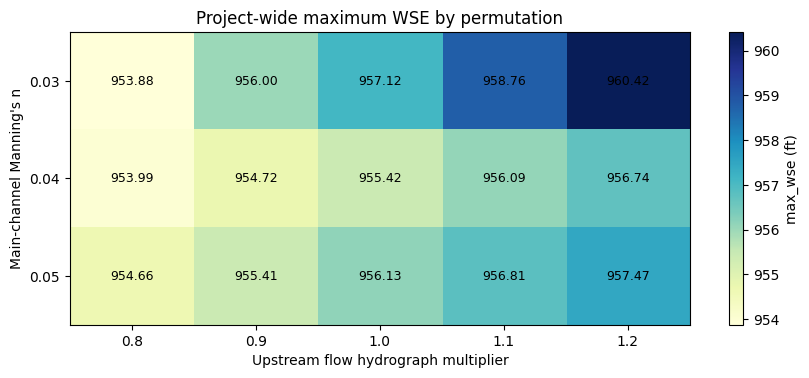

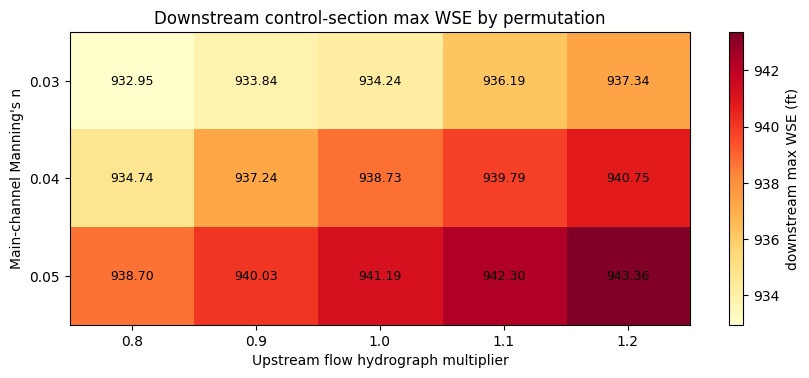

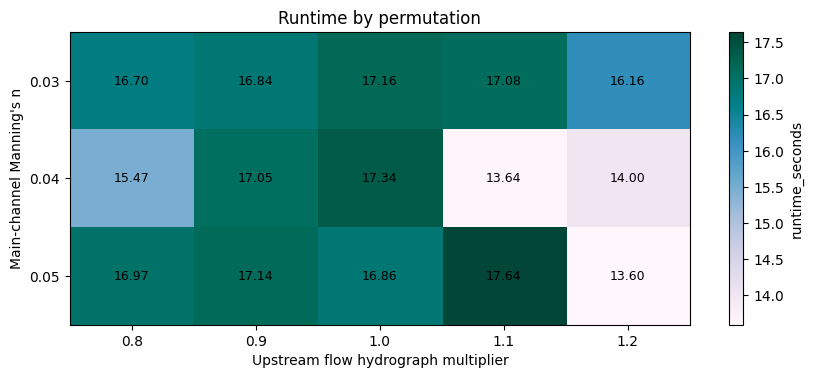

Autonomous interpretation
- All 15 permutations completed successfully.
- Increasing the inflow multiplier increased the downstream control-section WSE in every roughness slice: True.
- Increasing channel roughness increased the downstream control-section WSE in every inflow slice: True.
- Runtime was sensitive but not strictly monotonic with roughness in this small sweep (0.03 -> 16.8s, 0.04 -> 15.5s, 0.05 -> 16.4s; spread 4.0s). That suggests worker scheduling and pre/post-processing overhead are still visible at this model size.
- The project-wide max WSE was not strictly monotonic with roughness across all inflow multipliers: False. That suggests the controlling global maximum shifts location, so the downstream control section is the clearer sensitivity metric for this sweep.
- Highest project-wide max WSE: n=0.03, multiplier=1.2, max_wse=960.42 ft.
- Highest downstream control-section WSE: n=0.05, multiplier=1.2, downstream_max_wse=943.36 ft.
- Fastest run: n=0.05, multiplier=1.2,

,absolute_perm_id,channel_n,inflow_multiplier,max_wse,downstream_control_max_wse,runtime_seconds,delta_downstream_control_max_wse
0,15,0.05,1.2,957.466064,943.364502,13.595,4.635864
1,14,0.05,1.1,956.809326,942.302856,17.641,3.574219
2,13,0.05,1.0,956.125427,941.193970,16.859,2.465332
3,10,0.04,1.2,956.736267,940.754395,14.001,2.025757
4,12,0.05,0.9,955.410828,940.031006,17.141,1.302368
5,9,0.04,1.1,956.090271,939.794800,13.641,1.066162
6,8,0.04,1.0,955.419312,938.728638,17.344,0.000000
7,11,0.05,0.8,954.659485,938.702454,16.969,-0.026184
8,5,0.03,1.2,960.415710,937.337830,16.156,-1.390808
9,7,0.04,0.9,954.720398,937.240723,17.047,-1.487915


In [9]:
analysis_rows = []
for row in executed_df.itertuples(index=False):
    hdf_path = Path(row.hdf_path)
    xsec_ds = HdfResultsXsec.get_xsec_timeseries(hdf_path)
    station_lookup = {
        str(station): index
        for index, station in enumerate(
            xsec_ds["Station"].values.tolist()
        )
    }

    analysis_row = {
        "absolute_perm_id": row.absolute_perm_id,
    }
    for label, station in monitor_stations.items():
        station_index = station_lookup[station]
        analysis_row[f"{label}_max_wse"] = float(
            xsec_ds["Maximum_Water_Surface"].values[station_index]
        )
        analysis_row[f"{label}_max_flow"] = float(
            xsec_ds["Maximum_Flow"].values[station_index]
        )
    analysis_rows.append(analysis_row)

compiled_metrics_df = pd.DataFrame(analysis_rows)
compiled_results_df = (
    executed_df.merge(
        compiled_metrics_df,
        on="absolute_perm_id",
        how="left",
    )
    .sort_values(["channel_n", "inflow_multiplier"])
    .reset_index(drop=True)
)

baseline_mask = (
    np.isclose(compiled_results_df["channel_n"], base_channel_n)
    & np.isclose(compiled_results_df["inflow_multiplier"], 1.0)
)
assert baseline_mask.sum() == 1

baseline_row = compiled_results_df.loc[baseline_mask].iloc[0]
baseline_upstream_peak_cfs = float(
    baseline_row["upstream_boundary_max_flow"]
)
compiled_results_df["expected_upstream_peak_flow"] = (
    baseline_upstream_peak_cfs
    * compiled_results_df["inflow_multiplier"]
)
compiled_results_df["upstream_peak_flow_error_cfs"] = (
    compiled_results_df["upstream_boundary_max_flow"]
    - compiled_results_df["expected_upstream_peak_flow"]
)

assert (
    compiled_results_df["upstream_peak_flow_error_cfs"].abs().max()
    < 5.0
)

for column in [
    "max_wse",
    "mid_reach_max_wse",
    "downstream_control_max_wse",
    "runtime_seconds",
]:
    compiled_results_df[f"delta_{column}"] = (
        compiled_results_df[column] - float(baseline_row[column])
    )

compiled_results_path = plan_matrix["master_log"].with_name(
    plan_matrix["master_log"].stem + "_compiled_results.csv"
)
compiled_results_df.to_csv(compiled_results_path, index=False)

print(f"Compiled results saved to: {compiled_results_path}")
display(
    compiled_results_df[
        [
            "absolute_perm_id",
            "channel_n",
            "inflow_multiplier",
            "max_wse",
            "mid_reach_max_wse",
            "downstream_control_max_wse",
            "upstream_boundary_max_flow",
            "runtime_seconds",
        ]
    ]
)

global_pivot = compiled_results_df.pivot(
    index="channel_n",
    columns="inflow_multiplier",
    values="max_wse",
)
downstream_pivot = compiled_results_df.pivot(
    index="channel_n",
    columns="inflow_multiplier",
    values="downstream_control_max_wse",
)
runtime_pivot = compiled_results_df.pivot(
    index="channel_n",
    columns="inflow_multiplier",
    values="runtime_seconds",
)


def plot_heatmap(pivot_df, title, colorbar_label, cmap):
    fig, ax = plt.subplots(figsize=(10, 3.8))
    image = ax.imshow(pivot_df.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(
        [f"{value:.1f}" for value in pivot_df.columns]
    )
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(
        [f"{value:.2f}" for value in pivot_df.index]
    )
    ax.set_xlabel("Upstream flow hydrograph multiplier")
    ax.set_ylabel("Main-channel Manning's n")
    ax.set_title(title)

    for row_index in range(pivot_df.shape[0]):
        for col_index in range(pivot_df.shape[1]):
            ax.text(
                col_index,
                row_index,
                f"{pivot_df.iloc[row_index, col_index]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
            )

    plt.colorbar(image, ax=ax, label=colorbar_label)
    plt.show()


plot_heatmap(
    global_pivot,
    "Project-wide maximum WSE by permutation",
    "max_wse (ft)",
    "YlGnBu",
)
plot_heatmap(
    downstream_pivot,
    "Downstream control-section max WSE by permutation",
    "downstream max WSE (ft)",
    "YlOrRd",
)
plot_heatmap(
    runtime_pivot,
    "Runtime by permutation",
    "runtime_seconds",
    "PuBuGn",
)

ranked_df = compiled_results_df.sort_values(
    ["downstream_control_max_wse", "runtime_seconds"],
    ascending=[False, True],
).reset_index(drop=True)

downstream_monotonic_by_multiplier = (
    compiled_results_df.sort_values("inflow_multiplier")
    .groupby("channel_n")["downstream_control_max_wse"]
    .apply(lambda series: series.is_monotonic_increasing)
    .all()
)
downstream_monotonic_by_roughness = (
    compiled_results_df.sort_values("channel_n")
    .groupby("inflow_multiplier")["downstream_control_max_wse"]
    .apply(lambda series: series.is_monotonic_increasing)
    .all()
)
global_monotonic_by_roughness = (
    compiled_results_df.sort_values("channel_n")
    .groupby("inflow_multiplier")["max_wse"]
    .apply(lambda series: series.is_monotonic_increasing)
    .all()
)
mean_runtime_by_channel_n = (
    compiled_results_df.groupby("channel_n")["runtime_seconds"]
    .mean()
    .sort_index()
)

highest_global = compiled_results_df.loc[
    compiled_results_df["max_wse"].idxmax()
]
highest_downstream = compiled_results_df.loc[
    compiled_results_df["downstream_control_max_wse"].idxmax()
]
fastest_case = compiled_results_df.loc[
    compiled_results_df["runtime_seconds"].idxmin()
]

print("Autonomous interpretation")
print(
    f"- All {len(compiled_results_df)} permutations completed successfully."
)
print(
    "- Increasing the inflow multiplier increased the downstream "
    "control-section WSE in every roughness slice: "
    f"{downstream_monotonic_by_multiplier}."
)
print(
    "- Increasing channel roughness increased the downstream "
    "control-section WSE in every inflow slice: "
    f"{downstream_monotonic_by_roughness}."
)
runtime_summary = ", ".join(
    f"{channel_n:.2f} -> {runtime_value:.1f}s"
    for channel_n, runtime_value in mean_runtime_by_channel_n.items()
)
runtime_spread = (
    compiled_results_df["runtime_seconds"].max()
    - compiled_results_df["runtime_seconds"].min()
)
print(
    "- Runtime was sensitive but not strictly monotonic with "
    f"roughness in this small sweep ({runtime_summary}; spread "
    f"{runtime_spread:.1f}s). That suggests worker scheduling and "
    "pre/post-processing overhead are still visible at this model "
    "size."
)
print(
    "- The project-wide max WSE was not strictly monotonic with "
    "roughness across all inflow multipliers: "
    f"{global_monotonic_by_roughness}. "
    "That suggests the controlling global maximum shifts location, "
    "so the downstream control section is the clearer sensitivity "
    "metric for this sweep."
)
print(
    "- Highest project-wide max WSE: "
    f"n={highest_global['channel_n']:.2f}, "
    f"multiplier={highest_global['inflow_multiplier']:.1f}, "
    f"max_wse={highest_global['max_wse']:.2f} ft."
)
print(
    "- Highest downstream control-section WSE: "
    f"n={highest_downstream['channel_n']:.2f}, "
    f"multiplier={highest_downstream['inflow_multiplier']:.1f}, "
    f"downstream_max_wse="
    f"{highest_downstream['downstream_control_max_wse']:.2f} ft."
)
print(
    "- Fastest run: "
    f"n={fastest_case['channel_n']:.2f}, "
    f"multiplier={fastest_case['inflow_multiplier']:.1f}, "
    f"runtime={fastest_case['runtime_seconds']:.1f} seconds."
)

display(
    ranked_df[
        [
            "absolute_perm_id",
            "channel_n",
            "inflow_multiplier",
            "max_wse",
            "downstream_control_max_wse",
            "runtime_seconds",
            "delta_downstream_control_max_wse",
        ]
    ].head(10)
)


## Key Takeaways

- `RasPermutation.define_parameters()` turns a small parameter spec into
  a reproducible Cartesian product table with stable
  `absolute_perm_id` values.
- `apply_fn` can do real work, not just metadata edits. In this
  notebook each permutation gets its own cloned geometry and cloned
  unsteady flow file before execution.
- `RasPermutation.execute_and_summarize()` can drive the whole sweep with
  real HEC-RAS runs. Here it executes `15` permutations using `4`
  workers and `2` cores per worker.
- Compiling HDF outputs back into a single DataFrame makes the workflow
  reviewable and automation-friendly: the notebook saves a compiled CSV,
  ranks scenarios, and interprets the parameter response.
- Looking at both a project-wide max WSE and a monitoring station WSE is
  important. The global maximum can move around, while the downstream
  control section gives a clearer sensitivity signal for this 1D sweep.
